## Support Vector Classifier Implementation


In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay
%matplotlib inline

In [52]:
#Synthetic datapoints-(linearly separable)
from sklearn.datasets import make_classification

X,y = make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=1,n_redundant=0)
print(X.shape,y.shape)

(1000, 2) (1000,)


<Axes: >

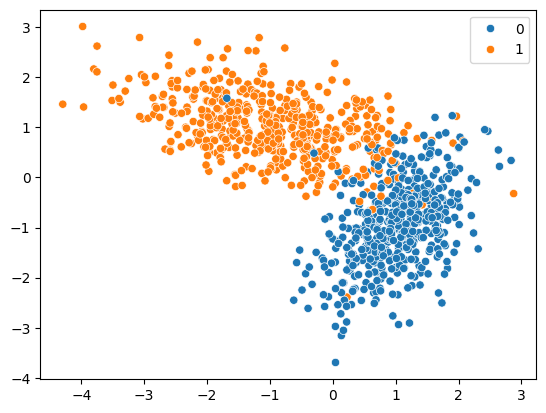

In [53]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)



In [54]:
from sklearn.svm import SVC
svc = SVC(kernel='linear')


In [55]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [56]:
svc.fit(X_train,y_train)

SVC(kernel='linear')

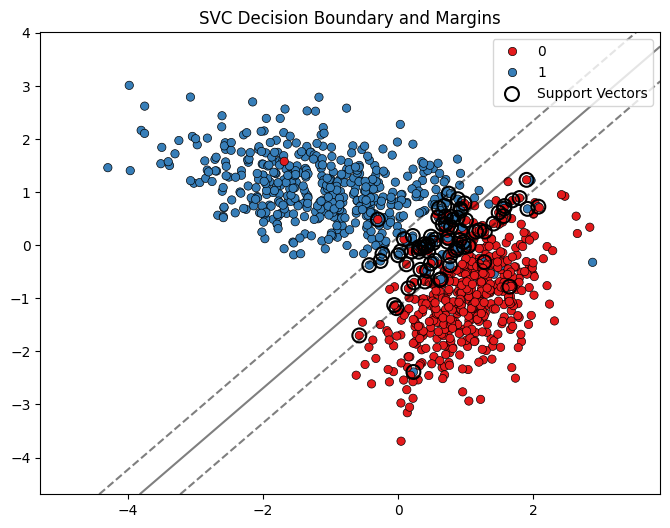

In [61]:
# 3. Create the base scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", edgecolor='k')

# 4. Plot the decision boundary and margins
DecisionBoundaryDisplay.from_estimator(
    svc,
    X,
    plot_method='contour',
    colors='k',               # Black lines
    levels=[-1, 0, 1],        # -1 and 1 are the margins, 0 is the decision boundary
    alpha=0.5,                # Transparency
    linestyles=['--', '-', '--'], # Dashed for margins, solid for the main boundary
    ax=plt.gca()              # Plot on the current axes
)

# Optional: Highlight the support vectors
plt.scatter(
    svc.support_vectors_[:, 0],
    svc.support_vectors_[:, 1],
    s=100, linewidth=1.5, facecolors='none', edgecolors='k', label='Support Vectors'
)

plt.title("SVC Decision Boundary and Margins")
plt.legend()
plt.show()

In [63]:
#prediction
y_pred = svc.predict(X_test)

In [64]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
#good accurancy as data points are linearly separable

              precision    recall  f1-score   support

           0       0.94      0.95      0.95       151
           1       0.96      0.95      0.96       179

    accuracy                           0.95       330
   macro avg       0.95      0.95      0.95       330
weighted avg       0.95      0.95      0.95       330

[[144   7]
 [  9 170]]
0.9515151515151515


(1000, 2) (1000,)


<Axes: >

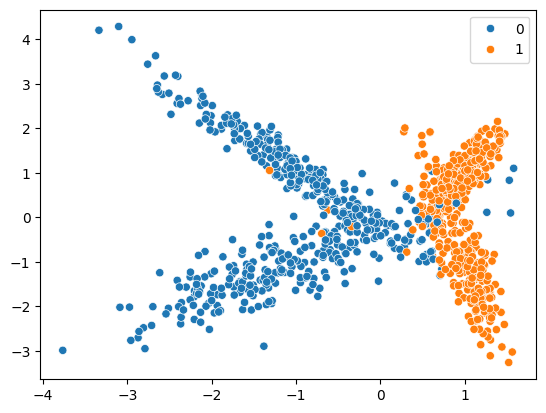

In [65]:
##Implementing different kernels for tranformation for non-linearly separable datasets

from sklearn.datasets import make_classification

X,y = make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=2,n_redundant=0)
print(X.shape,y.shape)
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)

In [66]:
rbf = SVC(kernel='rbf')
#expanding 1 dimension to make them separable wrt best fit plane.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
rbf.fit(X_train,y_train)

SVC()

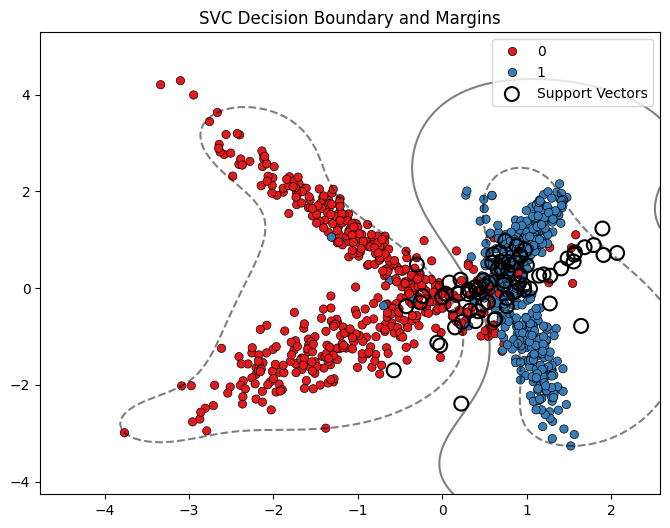

In [67]:
# 3. Create the base scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", edgecolor='k')

# 4. Plot the decision boundary and margins
DecisionBoundaryDisplay.from_estimator(
    rbf,
    X,
    plot_method='contour',
    colors='k',               # Black lines
    levels=[-1, 0, 1],        # -1 and 1 are the margins, 0 is the decision boundary
    alpha=0.5,                # Transparency
    linestyles=['--', '-', '--'], # Dashed for margins, solid for the main boundary
    ax=plt.gca()              # Plot on the current axes
)

# Optional: Highlight the support vectors
plt.scatter(
    svc.support_vectors_[:, 0],
    svc.support_vectors_[:, 1],
    s=100, linewidth=1.5, facecolors='none', edgecolors='k', label='Support Vectors'
)

plt.title("SVC Decision Boundary and Margins")
plt.legend()
plt.show()

In [49]:
y_pred = rbf.predict(X_test)

In [50]:
accuracy_score(y_test,y_pred)

0.9575757575757575

In [51]:
classification_report(y_test,y_pred)


'              precision    recall  f1-score   support\n\n           0       0.94      0.98      0.96       165\n           1       0.97      0.94      0.96       165\n\n    accuracy                           0.96       330\n   macro avg       0.96      0.96      0.96       330\nweighted avg       0.96      0.96      0.96       330\n'

In [68]:
#trying with polynomial kernel-
polynomial = SVC(kernel='poly')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
polynomial.fit(X_train,y_train)

SVC(kernel='poly')

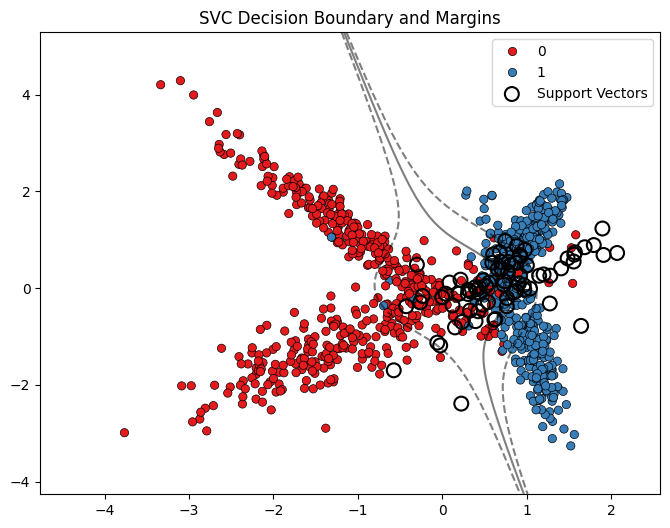

In [69]:
# 3. Create the base scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", edgecolor='k')

# 4. Plot the decision boundary and margins
DecisionBoundaryDisplay.from_estimator(
    polynomial,
    X,
    plot_method='contour',
    colors='k',               # Black lines
    levels=[-1, 0, 1],        # -1 and 1 are the margins, 0 is the decision boundary
    alpha=0.5,                # Transparency
    linestyles=['--', '-', '--'], # Dashed for margins, solid for the main boundary
    ax=plt.gca()              # Plot on the current axes
)

# Optional: Highlight the support vectors
plt.scatter(
    svc.support_vectors_[:, 0],
    svc.support_vectors_[:, 1],
    s=100, linewidth=1.5, facecolors='none', edgecolors='k', label='Support Vectors'
)

plt.title("SVC Decision Boundary and Margins")
plt.legend()
plt.show()

In [70]:
y_pred = polynomial.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.9181818181818182
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       154
           1       0.97      0.87      0.92       176

    accuracy                           0.92       330
   macro avg       0.92      0.92      0.92       330
weighted avg       0.92      0.92      0.92       330

[[150   4]
 [ 23 153]]


In [72]:
#testing with sigmoid-

sigmoid = SVC(kernel='sigmoid')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
sigmoid.fit(X_train,y_train)

SVC(kernel='sigmoid')

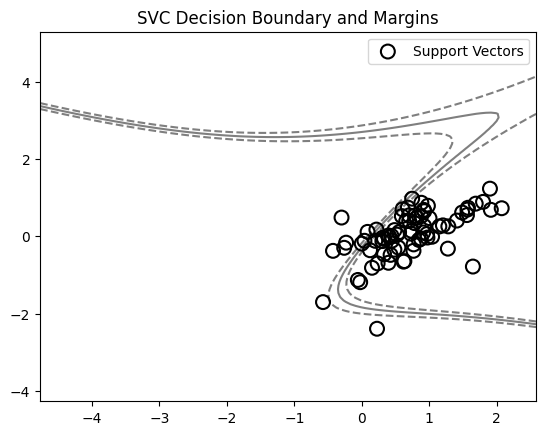

In [73]:
DecisionBoundaryDisplay.from_estimator(
    sigmoid,
    X,
    plot_method='contour',
    colors='k',               # Black lines
    levels=[-1, 0, 1],        # -1 and 1 are the margins, 0 is the decision boundary
    alpha=0.5,                # Transparency
    linestyles=['--', '-', '--'], # Dashed for margins, solid for the main boundary
    ax=plt.gca()              # Plot on the current axes
)

# Optional: Highlight the support vectors
plt.scatter(
    svc.support_vectors_[:, 0],
    svc.support_vectors_[:, 1],
    s=100, linewidth=1.5, facecolors='none', edgecolors='k', label='Support Vectors'
)

plt.title("SVC Decision Boundary and Margins")
plt.legend()
plt.show()

In [74]:
y_pred = polynomial.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.9181818181818182
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       154
           1       0.97      0.87      0.92       176

    accuracy                           0.92       330
   macro avg       0.92      0.92      0.92       330
weighted avg       0.92      0.92      0.92       330

[[150   4]
 [ 23 153]]


OBSERVATION - Rbf gives more accuracy by expanding one dimension and making the linearly unseparable dataset separable in a higher dimension.

In [75]:
#HYPERPARAMETER TUNING-
from sklearn.model_selection import GridSearchCV

# defining parameter range
param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf']}

In [77]:
grid= GridSearchCV(SVC(),param_grid=param_grid,cv=5,verbose=3,n_jobs=-1,refit=True)

In [78]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [79]:
grid.best_params_

{'C': 10, 'gamma': 1, 'kernel': 'rbf'}

In [81]:
y_pred= grid.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.9545454545454546
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       154
           1       0.94      0.97      0.96       176

    accuracy                           0.95       330
   macro avg       0.96      0.95      0.95       330
weighted avg       0.95      0.95      0.95       330

[[144  10]
 [  5 171]]


In [84]:
svc.coef_

array([[-1.66920361,  1.52302234]])

In [85]:
svc.intercept_

array([0.765818])

#SVM Kernels Indepth Intuition and Practical Implementation

In [179]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

x = np.linspace(-5.0, 5.0, 100)
y = np.sqrt(10**2 - x**2)
y=np.hstack([y,-y])
x=np.hstack([x,-x])

In [180]:
x1 = np.linspace(-5.0, 5.0, 100)
y1 = np.sqrt(5**2 - x1**2)
y1=np.hstack([y1,-y1])
x1=np.hstack([x1,-x1])

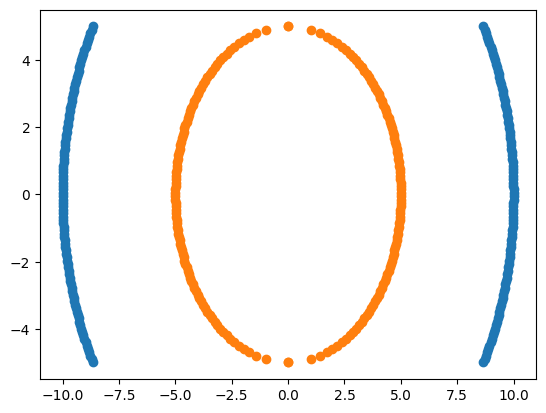

In [181]:
#Plotting data-
#cant plot a linear best fit SVC -- will result in low accuracy
plt.scatter(y,x)
plt.scatter(y1,x1)
plt.show()

In [183]:
#setting output features for inner and outer ring(Binary classification)
import pandas as pd
df1 =pd.DataFrame(np.vstack([y,x]).T,columns=['X1','X2'])
df1['Y']=0
df2 =pd.DataFrame(np.vstack([y1,x1]).T,columns=['X1','X2'])
df2['Y']=1
df = pd.concat([df1, df2], ignore_index=True)

df.head(5)

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [184]:
df.tail(5)

,X1,X2,Y
395,-1.969049,-4.59596,1
396,-1.714198,-4.69697,1
397,-1.406908,-4.79798,1
398,-0.999949,-4.89899,1
399,-0.000000,-5.00000,1


In [185]:
#Splitting features-
# Independent features (X): Drop the target column
X = df.drop('Y', axis=1)

# Dependent feature (y): Select only the target column
y = df['Y']

# Optional: Print the shapes to verify
print("Shape of X (Independent):", X.shape)
print("Shape of y (Dependent):", y.shape)

Shape of X (Independent): (400, 2)
Shape of y (Dependent): (400,)


In [186]:
from sklearn.model_selection import train_test_split

# Splitting the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Verify the shapes of the new datasets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (300, 2)
X_test shape: (100, 2)
y_train shape: (300,)
y_test shape: (100,)


In [187]:
classifier = SVC(kernel='linear',degree=1)
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
#low accuracy as the linear svc cant effectively separate the dependent features.

[[21 31]
 [18 30]]
              precision    recall  f1-score   support

           0       0.54      0.40      0.46        52
           1       0.49      0.62      0.55        48

    accuracy                           0.51       100
   macro avg       0.52      0.51      0.51       100
weighted avg       0.52      0.51      0.50       100

0.51


#POLYNOMIAL KERNEL-

$$K(x, x') = (\gamma \mathbf{x}^T \mathbf{x}' + r)^d$$


In [188]:
# 3 key components manually created for the Polynomial Kernel-
df['X1_square'] = df['X1']**2
df['X2_square'] = df['X2']**2
df['xy'] = df['X1']*df['X2']
df.head()

,X1,X2,Y,X1_square,X2_square,xy
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [189]:
#Splitting features-
# Independent features (X): Drop the target column
X = df.drop('Y', axis=1)

# Dependent feature (y): Select only the target column
y = df['Y']

# Optional: Print the shapes to verify
print("Shape of X (Independent):", X.shape)
print("Shape of y (Dependent):", y.shape)

Shape of X (Independent): (400, 5)
Shape of y (Dependent): (400,)


In [190]:
from sklearn.model_selection import train_test_split

# Splitting the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Verify the shapes of the new datasets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (300, 5)
X_test shape: (100, 5)
y_train shape: (300,)
y_test shape: (100,)


In [191]:
import plotly.express as px

fig = px.scatter_3d(df, x='X1', y='X2', z='xy',
              color='Y')
fig.show()
#No possibility of a linear svc to separate different categories.

In [192]:
fig = px.scatter_3d(df, x='X1_square', y='X2_square', z='xy',
              color='Y')

fig.show()

# Observation : When degree is extended by one ,we can see the linear svc (best fit hyperplane) can easily separate the two different categories

In [193]:
classifier = SVC(kernel='linear',degree=1)
#polynomial feature creates X1,X2,X1*X2
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
#100% accuracy

[[52  0]
 [ 0 48]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        48

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

1.0


In [194]:
#radial basis function kernel- transforms by expanding central datapts and segregating categories.
classifier = SVC(kernel='rbf',degree=1)
#polynomial feature creates X1,X2,X1*X2
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
#100% accuracy

[[52  0]
 [ 0 48]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        48

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

1.0


In [195]:
classifier = SVC(kernel='sigmoid',degree=1)
#polynomial feature creates X1,X2,X1*X2
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
#100% accuracy

[[52  0]
 [ 0 48]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        48

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

1.0


## Support Vector Regresssion Implementation

In [207]:
#tips dataset-
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df= sns.load_dataset('tips')
print(df)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


In [ ]:
#O/P feature- total_bill


In [208]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [209]:
df['sex'].value_counts()

,count
sex,
Male,157
Female,87


In [210]:
df['smoker'].value_counts()

,count
smoker,
No,151
Yes,93


In [211]:
df['day'].value_counts()

,count
day,
Sat,87
Sun,76
Thur,62
Fri,19


In [212]:
df['time'].value_counts()

,count
time,
Dinner,176
Lunch,68


In [213]:
##FEATURE ENCODING (Label and OHE)-
#For binary features, we will implement label encoding
#for categories >2 we will implement OHE.

X = df.drop(columns='total_bill')
y= df['total_bill']

In [214]:
#Train test split-(Before feature encoding)
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [215]:
X_train.head()

,tip,sex,smoker,day,time,size
115,3.50,Female,No,Sun,Dinner,2
181,5.65,Male,Yes,Sun,Dinner,2
225,2.50,Female,Yes,Fri,Lunch,2
68,2.01,Male,No,Sat,Dinner,2
104,4.08,Female,No,Sat,Dinner,2


In [216]:
#Feature Encoding-
from sklearn.preprocessing import LabelEncoder
le1 = LabelEncoder()
le2 = LabelEncoder()
le3 = LabelEncoder()



In [217]:
# Label Encoding for Binary features
X_train['sex'] = le1.fit_transform(X_train['sex'])
X_test['sex'] = le1.transform(X_test['sex'])

In [218]:
X_train['smoker'] = le2.fit_transform(X_train['smoker'])
X_test['smoker'] = le2.transform(X_test['smoker'])

In [219]:
X_train['time'] = le3.fit_transform(X_train['time'])
X_test['time'] = le3.transform(X_test['time'])

In [157]:
X_train.head()

,tip,sex,smoker,day,time,size
115,3.50,0,0,Sun,0,2
181,5.65,1,1,Sun,0,2
225,2.50,0,1,Fri,1,2
68,2.01,1,0,Sat,0,2
104,4.08,0,0,Sat,0,2


In [221]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Create a ColumnTransformer with OneHotEncoder for the 'day' column
ohe = OneHotEncoder()
ct = ColumnTransformer(
    transformers=[('onehot', OneHotEncoder(drop='first'), [3])],
    remainder='passthrough'
)



In [224]:
import sys
import numpy
numpy.set_printoptions (threshold=sys.maxsize)
X_train = ct.fit_transform(X_train)

In [225]:
X_test = ct.transform(X_test)

In [227]:
##SVR-- Support Vector Regressor
from sklearn.svm import SVR
svr = SVR()
svr.fit(X_train,y_train)

SVR()

In [228]:
y_pred = svr.predict(X_test)

In [231]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
r2_score(y_test,y_pred)

0.49798620106004743

In [232]:
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))


4.463296539661225
39.31122612339172
6.269866515595983


In [235]:
#HYPERPARAMETER TUNING-
from sklearn.model_selection import GridSearchCV

#defining parameter range-
# defining parameter range
param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf']}

grid = GridSearchCV(SVR(), param_grid, refit = True, verbose = 3)

#Fitting the model-
grid.fit(X_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.114 total time=   0.0s
[CV 2/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.008 total time=   0.0s
[CV 3/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.003 total time=   0.0s
[CV 4/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.015 total time=   0.0s
[CV 5/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.123 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.019 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.096 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.078 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.099 total time=   0.0s
[CV 5/5] END .....C=0.1, gamma=0.1, kernel=rbf;, score=-0.020 total time=   0.0s
[CV 1/5] END ....C=0.1, gamma=0.01, kernel=rbf;, score=-0.102 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(estimator=SVR(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [236]:
grid.best_params_

{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}

In [237]:
grid.best_score_

np.float64(0.5205632165395404)

In [239]:
#R2 increased by hyperparameter tuning-
y_pred = grid.predict(X_test)
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

0.5630727637616455
4.260483973872266
34.21448856486322
5.849315221875396
